# Aurora Bank: Fraud risk analysis and anomaly detection project

In [92]:
# importing libraries for manipulating data and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importing ml libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,precision_score,recall_score, f1_score, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import IsolationForest
from sklearn.utils.class_weight import compute_sample_weight


In [93]:
# loading the data
cards = pd.read_csv('/home/andi/Documents/Aurora Bank Challenge/csv files/cards_data.csv')
transactions = pd.read_csv('/home/andi/Documents/Aurora Bank Challenge/csv files/transactions_data.csv')

## Exploratory Data Analysis

#### Defining function to perform EDA

In [94]:
'''The following function allows me to easily conduct basic EDA on the 5 dataframes without having to repeatedly write the same codes'''

def preview_df(df, name="DataFrame", head_n=5):
    print(f"{name.upper()}")
    
    # Shape
    print(f"\nShape: {df.shape}")
    
    # Info
    print("\nInfo:")
    df.info()
    
    # Missing values
    print("\nMissing Values:")
    display(df.isna().sum())
    
    # Duplicates
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")
    
    # Describe (include categorical too)
    print("\nSummary Statistics:")
    display(df.describe())
    
    # Head
    print(f"\nFirst {head_n} rows:")
    display(df.head(head_n))


#### EDA: Cards data

In [95]:
preview_df(cards)


DATAFRAME

Shape: (6146, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     6146 non-null   int64  
 1   client_id              6146 non-null   int64  
 2   card_brand             6146 non-null   object 
 3   card_type              6146 non-null   object 
 4   card_number            6146 non-null   int64  
 5   expires                6146 non-null   object 
 6   cvv                    6146 non-null   int64  
 7   has_chip               6146 non-null   object 
 8   num_cards_issued       6146 non-null   int64  
 9   credit_limit           6146 non-null   float64
 10  acct_open_date         6146 non-null   object 
 11  year_pin_last_changed  6146 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 576.3+ KB

Missing Values:


id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,id,client_id,card_number,cvv,num_cards_issued,credit_limit,year_pin_last_changed
count,6146.000000,6146.000000,6.146000e+03,6146.000000,6146.000000,6146.000000,6146.000000
mean,3072.500000,994.939636,4.820426e+15,506.220794,1.503091,14347.493980,2013.436707
std,1774.341709,578.614626,1.328582e+15,289.431123,0.519191,12014.463884,4.270699
min,0.000000,0.000000,3.001055e+14,0.000000,1.000000,0.000000,2002.000000
25%,1536.250000,492.250000,4.486365e+15,257.000000,1.000000,7042.750000,2010.000000
50%,3072.500000,992.000000,5.108957e+15,516.500000,1.000000,12592.500000,2013.000000
75%,4608.750000,1495.000000,5.585237e+15,756.000000,2.000000,19156.500000,2017.000000
max,6145.000000,1999.000000,6.997197e+15,999.000000,3.000000,151223.000000,2020.000000



First 5 rows:


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
0,4524,825,Visa,Debit,4344676511950440,2022-12-01,623,YES,2,24295.0,2002-09-01,2008
1,2731,825,Visa,Debit,4956965974959980,2020-12-01,393,YES,2,21968.0,2014-04-01,2014
2,3701,825,Visa,Debit,4582313478255490,2024-02-01,719,YES,2,46414.0,2003-07-01,2004
3,42,825,Visa,Credit,4879494103069050,2024-08-01,693,NO,1,12400.0,2003-01-01,2012
4,4659,825,Mastercard,Debit (Prepaid),5722874738736010,2009-03-01,75,YES,1,28.0,2008-09-01,2009


* Columns: `expires` and `acct_open_date` will be changed to datetime format.
* I can see that the data has no missing or duplicated values.

In [96]:
cards['expires'] = pd.to_datetime(cards['expires'])
cards['acct_open_date'] = pd.to_datetime(cards['acct_open_date'])

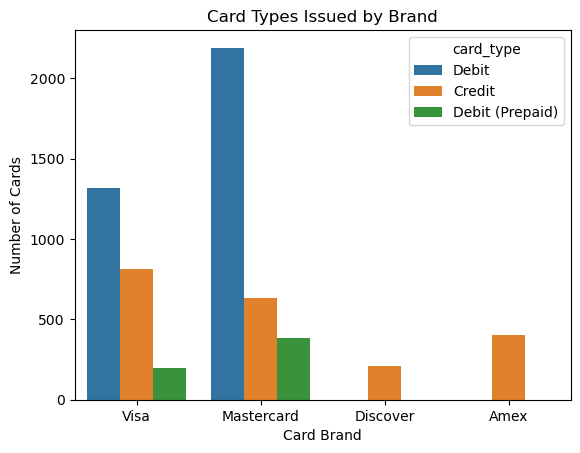

In [97]:
plt.figure()
sns.countplot(data=cards, x='card_brand', hue='card_type')
plt.title('Card Types Issued by Brand')
plt.xlabel('Card Brand')
plt.ylabel('Number of Cards')
plt.show()

#### EDA: Transactions data

In [98]:
preview_df(transactions)

DATAFRAME

Shape: (157224, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157224 entries, 0 to 157223
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              157224 non-null  int64  
 1   date            157224 non-null  object 
 2   client_id       157224 non-null  int64  
 3   card_id         157224 non-null  int64  
 4   amount          157224 non-null  float64
 5   use_chip        157224 non-null  object 
 6   merchant_id     157224 non-null  int64  
 7   merchant_city   157224 non-null  object 
 8   merchant_state  139303 non-null  object 
 9   zip             138118 non-null  float64
 10  mcc             157224 non-null  int64  
 11  errors          2738 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 14.4+ MB

Missing Values:


id                     0
date                   0
client_id              0
card_id                0
amount                 0
use_chip               0
merchant_id            0
merchant_city          0
merchant_state     17921
zip                19106
mcc                    0
errors            154486
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,id,client_id,card_id,amount,merchant_id,zip,mcc
count,1.572240e+05,157224.000000,157224.000000,157224.000000,157224.000000,138118.000000,157224.000000
mean,2.131993e+07,244.470170,3472.708403,43.724136,47876.177066,52374.559732,5581.750776
std,1.409058e+06,147.294551,1638.186960,81.088546,26009.159493,29720.519620,876.443164
min,1.888158e+07,0.000000,19.000000,-500.000000,37.000000,1010.000000,1711.000000
25%,2.009929e+07,114.000000,2426.000000,8.590000,25887.000000,28657.000000,5300.000000
50%,2.131298e+07,235.000000,3581.000000,31.140000,45453.000000,48235.000000,5499.000000
75%,2.253801e+07,373.000000,4841.000000,66.232500,68671.000000,78413.000000,5812.000000
max,2.376182e+07,497.000000,6133.000000,1911.540000,100340.000000,99829.000000,9402.000000



First 5 rows:


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,23565628,2024-09-20 08:43:00,44,5748,60.00,Chip Transaction,27092,Medford,OR,97501.0,4829,Bad PIN
1,23252317,2024-07-15 21:19:00,327,3063,20.00,Chip Transaction,27092,Bloomfield,CT,6002.0,4829,Bad PIN
2,22878540,2024-04-27 18:21:00,233,1297,0.00,Chip Transaction,27092,Minneapolis,MN,55433.0,4829,Bad PIN
3,23402443,2024-08-16 14:44:00,114,3398,92.00,Chip Transaction,59935,North Hollywood,CA,91606.0,5499,Bad PIN
4,23267370,2024-07-19 08:16:00,157,1052,23.66,Chip Transaction,59935,Perris,CA,92571.0,5499,Bad PIN


* Column `date` will be changed to timestamp
* I will investigate the null values `merchant_state` and `zip`
* The null values in `errors` column are expected because other transactions complete successfully

In [99]:
transactions['date'] = pd.to_datetime(transactions['date'])

In [100]:
print(f'The earliest transaction date is: {transactions['date'].min()} and the last is: {transactions['date'].max()}')

The earliest transaction date is: 2022-01-01 01:43:00 and the last is: 2024-10-31 23:06:00


In [101]:
# selecting only the state and zip with missing values
missing_location = transactions[transactions['merchant_state'].isna() & transactions['zip'].isna()]

# the cities associated with missing locations
missing_location['merchant_city'].value_counts()

merchant_city
ONLINE    17921
Name: count, dtype: int64

* Online transactions have no recorded `merchant_state` and `zip`. Therefore, I will be replacing the null values with `online`.

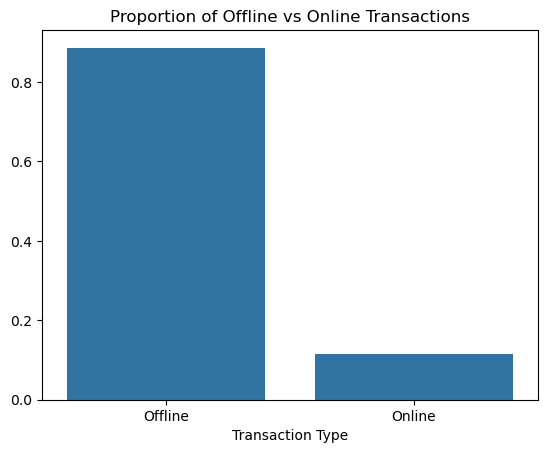

In [102]:
online_offline = np.where(transactions['merchant_city'] == 'ONLINE', 'Online','Offline')

plt.figure()
sns.countplot(x=online_offline, stat='proportion')
plt.title('Proportion of Offline vs Online Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('')
plt.show()

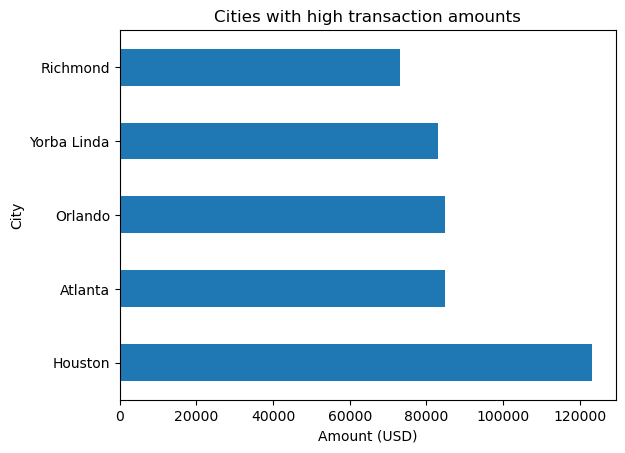

In [103]:
top_5_cities = transactions.groupby('merchant_city')['amount'].sum().sort_values(ascending=False)
top_5_cities = top_5_cities.drop('ONLINE').head(5)


plt.figure()
top_5_cities.plot(kind='barh')
plt.title('Cities with high transaction amounts')
plt.xlabel('Amount (USD)')
plt.ylabel('City')
plt.show()

In [104]:
transactions['errors'].value_counts()

errors
Insufficient Balance                     1760
Bad PIN                                   388
Technical Glitch                          324
Bad Card Number                            93
Bad Expiration                             73
Bad CVV                                    65
Bad Zipcode                                17
Bad PIN,Insufficient Balance                6
Bad CVV,Insufficient Balance                3
Insufficient Balance,Technical Glitch       3
Bad Card Number,Bad CVV                     2
Bad Card Number,Technical Glitch            1
Bad Expiration,Bad CVV                      1
Bad Card Number,Insufficient Balance        1
Bad PIN,Technical Glitch                    1
Name: count, dtype: int64

* I can see that the errors are coded in a way that lists a single error as well as a combination of errors. Because of the low volume of dual errors, I will not be focusing on them when defining fraud rules.
* It is interesting though to see how many transactions resulted in `Insufficient Balance`. 

## Building Classification Model
In order to build a good model, I need to create a proper dataframe. Right now, my data is scattered in 4 different dataframes. So, the next steps are to:
* Merge dataframes
* Create new features - e.g., online and offline transactions
* Define and create fraud rules

# Feature Engineering

#### Merging Dataframes

In [105]:
merged_df = transactions.merge(cards[['expires', 'year_pin_last_changed', 'credit_limit']], how='left', left_on=transactions['card_id'], right_on=cards['id'])
merged_df.head()

,key_0,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,expires,year_pin_last_changed,credit_limit
0,5748,23565628,2024-09-20 08:43:00,44,5748,60.00,Chip Transaction,27092,Medford,OR,97501.0,4829,Bad PIN,2022-05-01,2007,3400.0
1,3063,23252317,2024-07-15 21:19:00,327,3063,20.00,Chip Transaction,27092,Bloomfield,CT,6002.0,4829,Bad PIN,2021-06-01,2010,13322.0
2,1297,22878540,2024-04-27 18:21:00,233,1297,0.00,Chip Transaction,27092,Minneapolis,MN,55433.0,4829,Bad PIN,2024-03-01,2012,13700.0
3,3398,23402443,2024-08-16 14:44:00,114,3398,92.00,Chip Transaction,59935,North Hollywood,CA,91606.0,5499,Bad PIN,2023-07-01,2010,27447.0
4,1052,23267370,2024-07-19 08:16:00,157,1052,23.66,Chip Transaction,59935,Perris,CA,92571.0,5499,Bad PIN,2020-11-01,2011,10644.0


In [106]:
merged_df=merged_df.drop('key_0', axis=1)
merged_df.duplicated().sum() # checking duplicates after merging

np.int64(0)

In [107]:
merged_df.isna().sum()

id                            0
date                          0
client_id                     0
card_id                       0
amount                        0
use_chip                      0
merchant_id                   0
merchant_city                 0
merchant_state            17921
zip                       19106
mcc                           0
errors                   154486
expires                       0
year_pin_last_changed         0
credit_limit                  0
dtype: int64

In [108]:
merged_df['use_chip'].value_counts()

use_chip
Chip Transaction      112114
Swipe Transaction      27327
Online Transaction     17783
Name: count, dtype: int64

#### New columns to add:
* daily trancation amount per account
* total daily transaction count for each account
* transaction frequency for each transactions
* previous transaction time
* transaction type (online or offline)

#### Handling missing values
* use value 'online' to fillna on `merchant_state` and `zip` 

## Feature Engineering

In [109]:
def engineer_features(df):

    df = df.copy()

    df = df.sort_values(['client_id', 'card_id', 'date']).reset_index(drop=True)

    df['date_only'] = df['date'].dt.date

    # Online vs Offline
    df['transaction_channel'] = np.where(df['merchant_city'].eq('ONLINE'),'Online','Offline')

    # Daily spend
    df['daily_transaction_amount'] = (df.groupby(['client_id', 'date_only'])['amount'].transform('sum'))

    # Daily transaction count
    df['daily_transaction_count'] = (df.groupby(['client_id', 'date_only'])['amount'].transform('count'))

    # Previous transaction
    df['prev_transaction_time'] = (df.groupby('client_id')['date'].shift())

    # Minutes since last transaction
    df['minutes_since_last_trans'] = ((df['date'] - df['prev_transaction_time']).dt.total_seconds()/ 60)

    # Hour
    df['transaction_hour'] = df['date'].dt.hour

    # Day of week
    df['day_of_week'] = df['date'].dt.dayofweek

    return df

### Fraud Rules

In [110]:
'''the following 6 functions define 6 different fraud rules'''

# 1. amount spike
def rule_amount_spike(df, z_threshold=3):

    grp = df.groupby('client_id')['amount']

    mean = grp.transform('mean')
    std = grp.transform('std').fillna(0)

    return df['amount'] > (mean + z_threshold * std)

# 2. high daily spend
def rule_high_daily_spend(df, multiplier=3):

    avg_daily = (df.groupby('client_id')['daily_transaction_amount'].transform('mean'))

    return (df['daily_transaction_amount'] > avg_daily * multiplier)

# 3. high daily transaction count
def rule_high_daily_count(df, threshold=10):

    return (df['daily_transaction_count'] > threshold)

# 4. rapid fire transactions
def rule_rapid_fire(df, minutes=1):

    return (df['minutes_since_last_trans'] < minutes)

# 5. transactions with expired cards
def rule_expired_card(df):

    return (df['date']> df['expires'])

# 6. transactions at unusual hours
def rule_unusual_hour(df):

    hour = df['transaction_hour']

    return ((hour >= 0) & (hour <= 5))



In [111]:

'''the following function applies the above fraud rules'''

def apply_rules(df):

    df = df.copy()

    df['amount_spike_flag'] = rule_amount_spike(df)

    df['high_daily_spend_flag'] = (rule_high_daily_spend(df))

    df['high_daily_count_flag'] = (rule_high_daily_count(df))

    df['rapid_fire_flag'] = (rule_rapid_fire(df))

    df['expired_card_flag'] = (rule_expired_card(df))

    df['unusual_hour_flag'] = (rule_unusual_hour(df))

    return df

### Fraud Rule Risk Score

In [112]:
# applying the function to the dataframe
merged_df = engineer_features(merged_df)

merged_df = apply_rules(merged_df)

In [113]:
flag_columns = ['amount_spike_flag', 'high_daily_spend_flag', 'high_daily_count_flag', 'rapid_fire_flag', 'expired_card_flag', 'unusual_hour_flag']

merged_df['rule_score'] = merged_df[flag_columns].sum(axis=1)

In [114]:
merged_df['rule_score'].value_counts()

rule_score
1    100684
0     41783
2     13002
3      1643
4       112
Name: count, dtype: int64

* The interpretation of the rule scores is like this:

| Score | Risk   |
| ----- | ------ |
| 0     | Low    |
| 1     | Low    |
| 2     | Medium |
| 3+    | High   |


#### Exploring flagged transactions

In [115]:
rule_summary = (merged_df[flag_columns].sum().sort_values(ascending=False))

print(rule_summary)

expired_card_flag        109379
unusual_hour_flag         10116
high_daily_spend_flag      9959
amount_spike_flag          1863
rapid_fire_flag             748
high_daily_count_flag         0
dtype: int64


* It seems that the most common flag is from people attempting transactions using expired cards.

In [116]:
high_risk = merged_df[merged_df['rule_score'] >= 3]

print(high_risk.shape)

(1755, 30)


In [117]:
high_risk[['client_id', 'date', 'amount', 'merchant_city', 'rule_score']].head(20)

,client_id,date,amount,merchant_city,rule_score
308,0,2024-03-30 06:45:00,535.73,Stratford,3
439,0,2022-07-14 13:49:00,385.60,Scarborough,3
448,0,2022-08-03 21:39:00,363.00,Old Orchard Beach,3
455,0,2022-09-08 05:55:00,594.20,Ansonia,4
485,0,2023-01-21 12:05:00,819.18,Baltimore,3
503,0,2023-04-01 23:07:00,443.00,Waianae,3
522,0,2023-06-03 20:27:00,338.00,Marysville,3
547,0,2023-10-17 18:40:00,508.02,Lewiston,3
559,0,2023-12-14 14:17:00,334.63,Springvale,3
589,0,2024-04-22 14:16:00,357.98,Springvale,3


# Isolation Forest
Building an isolation forest model for detecting anomalies.

In [118]:
#  selecting features
iso_features = ['amount','credit_limit','daily_transaction_amount','daily_transaction_count','minutes_since_last_trans', 'transaction_hour']

X = (merged_df[iso_features].fillna(0))

# fitting the model
iso = IsolationForest(contamination=0.01,random_state=42)


merged_df['anomaly_label'] = iso.fit_predict(X)
merged_df['anomaly_scores'] = iso.decision_function(X)

merged_df['is_anomaly'] = (merged_df['anomaly_label'] == -1)

pd.crosstab(merged_df['rule_score'] >= 3,merged_df['is_anomaly'], margins=True)

is_anomaly,False,True,All
rule_score,,,
False,154526,943,155469
True,1125,630,1755
All,155651,1573,157224


In [119]:
agreed_suspicious = merged_df[(merged_df['rule_score'] >= 3) & (merged_df['is_anomaly'])]
agreed_suspicious.tail(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,amount_spike_flag,high_daily_spend_flag,high_daily_count_flag,rapid_fire_flag,expired_card_flag,unusual_hour_flag,rule_score,anomaly_label,anomaly_scores,is_anomaly
156165,23492555,2024-09-04 17:05:00,494,2333,597.06,Chip Transaction,97130,Villa Park,IL,60181.0,...,True,True,False,False,True,False,3,-1,-0.000987,True
156301,21827042,2023-09-17 00:51:00,494,3273,406.00,Chip Transaction,7777,Nassau,The Bahamas,NaN,...,True,True,False,False,True,True,4,-1,-0.047314,True
156364,22811642,2024-04-13 15:56:00,494,3273,983.44,Swipe Transaction,38489,Suitland,MD,20746.0,...,True,True,False,False,True,False,3,-1,-0.065060,True
156519,22444423,2024-01-25 22:49:00,496,3428,632.81,Online Transaction,6063,ONLINE,NaN,NaN,...,True,True,False,False,True,False,3,-1,-0.053805,True
156632,21268863,2023-05-21 23:40:00,496,5806,460.00,Chip Transaction,44795,Anchorage,AK,99504.0,...,True,True,False,False,True,False,3,-1,-0.028789,True
156642,22042372,2023-11-01 18:17:00,496,5806,454.98,Chip Transaction,7257,Houston,TX,77049.0,...,True,True,False,False,True,False,3,-1,-0.000636,True
156852,21593783,2023-07-29 14:45:00,497,2829,1196.21,Chip Transaction,57386,Saint Louis,MO,63136.0,...,True,True,False,False,True,False,3,-1,-0.056446,True
157173,19569488,2022-05-26 22:31:00,497,3879,1234.37,Swipe Transaction,95676,Glendale,AZ,85301.0,...,True,True,False,False,True,False,3,-1,-0.076360,True
157203,21535743,2023-07-17 13:48:00,497,3879,472.23,Chip Transaction,32282,Sioux Falls,SD,57110.0,...,True,True,False,False,True,False,3,-1,-0.092441,True
157205,22055508,2023-11-04 12:46:00,497,3879,524.60,Chip Transaction,85600,Chicago,IL,60613.0,...,True,True,False,False,True,False,3,-1,-0.040871,True


In [120]:
print(f"Transactions: {len(merged_df):,}")

print(f"Rule flagged: {(merged_df['rule_score'] >= 3).sum():,}")

print(f"Isolation Forest anomalies: {merged_df['is_anomaly'].sum():,}")

print(f"Both methods: {len(agreed_suspicious):,}")

Transactions: 157,224
Rule flagged: 1,755
Isolation Forest anomalies: 1,573
Both methods: 630


#### Visualising anomalies

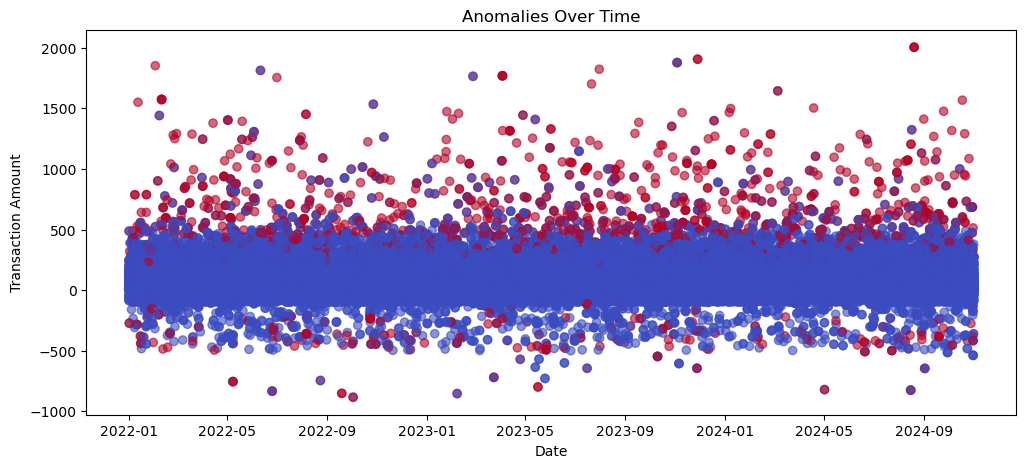

In [121]:
plt.figure(figsize=(12, 5))

plt.scatter(
    merged_df['date'],
    merged_df['daily_transaction_amount'],
    c=(merged_df['anomaly_label'] == -1),
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel("Date")
plt.ylabel("Transaction Amount")
plt.title("Anomalies Over Time")
plt.show()

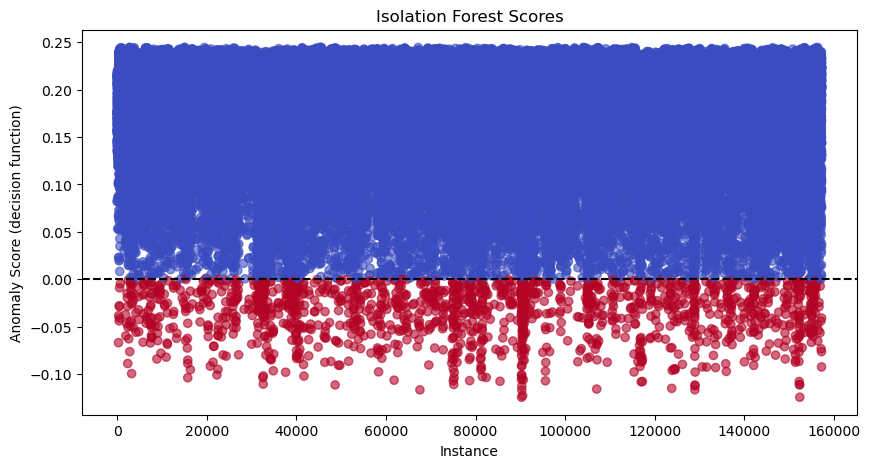

In [122]:
# Visualisation of the results
plt.figure(figsize=(10, 5))

plt.scatter(merged_df.index,merged_df['anomaly_scores'],c=(merged_df['anomaly_label'] == -1),cmap='coolwarm',alpha=0.6)

plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Instance")
plt.ylabel("Anomaly Score (decision function)")
plt.title("Isolation Forest Scores")
plt.show()

The 1755 instances with the lowest anomaly scores are given in red.

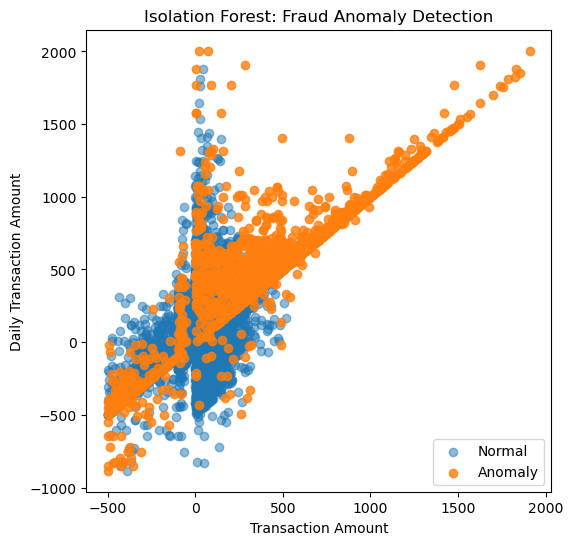

In [123]:
# Visualisation of Isolation Forest results
plt.figure(figsize=(6, 6))

# Normal transactions
normal = merged_df[merged_df['anomaly_label'] == 1]

# Anomalies
anomalies = merged_df[merged_df['anomaly_label'] == -1]

# Scatter plot: Amount vs Daily Spend
plt.scatter(
    normal['amount'],
    normal['daily_transaction_amount'],
    label='Normal',
    alpha=0.5
)

plt.scatter(
    anomalies['amount'],
    anomalies['daily_transaction_amount'],
    label='Anomaly',
    alpha=0.8
)

plt.xlabel("Transaction Amount")
plt.ylabel("Daily Transaction Amount")
plt.title("Isolation Forest: Fraud Anomaly Detection")
plt.legend()
plt.show()

# Comparing other tree-based models: Random Forest and HistGradient Boosting
What these two models are doing is weakly supervised fraud detection using 'business rules' as proxy labels. It is  not 'true fraud'

In [125]:
# Fraud is triggered by at least 2 rules
merged_df['fraud_label'] = (merged_df[flag_columns].sum(axis=1) >= 2).astype(int)

# feature selection
feature_cols = ['amount','credit_limit', 'daily_transaction_amount','daily_transaction_count','minutes_since_last_trans','transaction_hour']

# training and split
X = merged_df[feature_cols].fillna(0)
y = merged_df['fraud_label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42,stratify=y)

# class imbalance
sample_weight = compute_sample_weight(class_weight='balanced',y=y_train)

# random forest
rf = RandomForestClassifier(n_estimators=300,max_depth=None,random_state=42,n_jobs=-1)

rf.fit(X_train, y_train, sample_weight=sample_weight)

# histgradient
hgb = HistGradientBoostingClassifier(max_depth=8,learning_rate=0.05, max_iter=300, random_state=42)

hgb.fit(X_train, y_train)

# predictions
rf_pred = rf.predict(X_test)
hgb_pred = hgb.predict(X_test)

# model evaluations
# random forest
print("Random Forest")
print(classification_report(y_test, rf_pred))

rf_proba = rf.predict_proba(X_test)[:, 1]
print("PR AUC:", average_precision_score(y_test, rf_proba))

# histgradient
print("HistGradientBoosting")
print(classification_report(y_test, hgb_pred))

hgb_proba = hgb.predict_proba(X_test)[:, 1]
print("PR AUC:", average_precision_score(y_test, hgb_proba))

Random Forest
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     42741
           1       0.78      0.68      0.72      4427

    accuracy                           0.95     47168
   macro avg       0.87      0.83      0.85     47168
weighted avg       0.95      0.95      0.95     47168

PR AUC: 0.823917840916528
HistGradientBoosting
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     42741
           1       0.77      0.74      0.75      4427

    accuracy                           0.95     47168
   macro avg       0.87      0.86      0.86     47168
weighted avg       0.95      0.95      0.95     47168

PR AUC: 0.8431935152037093


HistGradient model is the better performer with:
* Higher recall 0.74
* Higher PR AUC 0.843
* Slightly better F1